In [1]:
import numpy as np
import scanpy as sc
import anndata as ad
import pandas as pd
import scipy
import os
import torch
from matplotlib import pyplot as plt
from umap import UMAP
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import sys; sys.path += ['./../../']
from CardamomOT import NetworkModel as CardamomNetworkModel
from CardamomOT.inference.simulations import kon_ref, simulate_next_prot_ode
from harissa import NetworkModel as HarissaNetworkModel

# Model fit

In [2]:
cmap = plt.get_cmap('tab20')
colors_methods = {'CARDAMOM2': (cmap(6), cmap(7)), 'CARDAMOM1': (cmap(8), cmap(9)),'REFERENCE_FITTING': (cmap(18), cmap(19)),
    'GENIE3': (cmap(0), cmap(1)), 'SINCERITIES': (cmap(2), cmap(3)),
    'PIDC': (cmap(4), cmap(5)), 'PEARSON': (cmap(14), cmap(15)),
    'SCRIBE_timed': (cmap(10), cmap(11)), 'SCRIBE_wadd': (cmap(12), cmap(13)),
    'SCRIBE_pseudotimed': (cmap(16), cmap(17)), 'Random': 2*('lightgray',)}

In [ ]:
def simulate_from_adata(adata, time_key="time", umap_min_dist=0.7, umap_random_state=42, verb=1):
    time_vals = np.array(adata.obs[time_key])
    if scipy.sparse.issparse(adata.X):
        x = adata.X.toarray().copy()
    else:
        x = adata.X.copy()
    x = np.insert(x, 0, time_vals, axis=1)
    G = np.size(x, 1)
    model = CardamomNetworkModel(G - 1)
    print(x.shape)
    model.fit_mixture(x, gene_names=list(adata.var_names), 
                      min_components=2, max_components=2, max_iter_kinetics=0, verb=verb)
    model.fit_network(x, intensity_prior=100, verb=verb)
    model.adapt_to_unitary()
    model.simulate_network(np.unique(time_vals))

    c = model.a[-1]
    ks_cells = np.max(model.a[:-1], axis=0)
    pi_zinb = model.pi

    data_sim = np.random.negative_binomial(
        (ks_cells * model.kon_theta)[:, 1:].T,
        (c / (c + 1))[1:].reshape(G - 1, 1),
    )
    zero_mask = (np.random.uniform(0, 1, data_sim.shape) < pi_zinb.reshape((G - 1, 1)))
    print("new zeros ratio sim: ", np.sum(zero_mask == 1) / np.size(data_sim[1:, :]))
    data_sim = np.where(zero_mask, 0, data_sim)

    umap_model = UMAP(n_components=2, random_state=umap_random_state, min_dist=umap_min_dist)
    data_traj_2d = umap_model.fit_transform(adata.X.toarray() if scipy.sparse.issparse(adata.X) else adata.X)
    sim_traj_2d = umap_model.transform(data_sim.T)

    return data_sim, data_traj_2d, sim_traj_2d, model.times_simul

In [4]:
adata_schiebinger = sc.read('../../../../data/Datas_exp/Schiebinger/Data/data_train.h5ad')

In [5]:
n_per_time = 100
np.random.seed(0)
time_vals = np.array(adata_schiebinger.obs['time'])
subsample_indices = []
for t in np.unique(time_vals):
    time_indices = np.where(time_vals == t)[0]
    n_sample = min(n_per_time, len(time_indices))
    sampled = np.random.choice(time_indices, size=n_sample, replace=False)
    subsample_indices.extend(sampled)
adata_schiebinger = adata_schiebinger[np.array(subsample_indices)].copy()

In [6]:
time_schiebinger = np.array(adata_schiebinger.obs["time"])
data_sim_schiebinger, data_schiebinger_traj_2d, sim_schiebinger_traj_2d, schiebinger_times_simul = simulate_from_adata(
    adata_schiebinger)

(3658, 109)


2026-02-09 22:34:34.156955: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 22:34:34.199015: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 22:34:34.243740: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 22:34:34.269548: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 22:34:34.311766: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 22:34:34.330085: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 22:34:34.379776: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 22:34:34.402712: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-

Calibrating gene 3
Calibrating gene 10
Calibrating gene 8
Calibrating gene 18
Calibrating gene 9
Calibrating gene 7
Calibrating gene 14
Calibrating gene 17
Calibrating gene 11
Calibrating gene 5
Calibrating gene 15
Calibrating gene 1
Calibrating gene 4
Calibrating gene 12
Calibrating gene 19
Calibrating gene 6
Calibrating gene 20
Calibrating gene 16
Calibrating gene 13
Calibrating gene 2
Calibrating gene 21
Calibrating gene 22
Calibrating gene 23
Calibrating gene 24
Calibrating gene 25
Calibrating gene 26
Calibrating gene 27
Calibrating gene 28
Calibrating gene 29
Calibrating gene 30
Calibrating gene 31
Calibrating gene 32
Calibrating gene 33
Calibrating gene 34
Calibrating gene 35
Calibrating gene 36
Calibrating gene 37
Calibrating gene 38
Calibrating gene 39
Calibrating gene 40
Calibrating gene 41
Calibrating gene 42
Calibrating gene 43
Calibrating gene 44
Calibrating gene 45
Calibrating gene 46
Calibrating gene 47
Calibrating gene 48
Calibrating gene 49
Calibrating gene 50
Calibrati

/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


2 0 | Errors (before, after): 0.38840, 0.38367 | alpha mean: 0.1158
number of non reached cells 1314


...

/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


9 0 | Errors (before, after): 0.33959, 0.33780 | alpha mean: 0.2925
number of non reached cells 1120


/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(
/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


10 0 | Errors (before, after): 0.33431, 0.33222 | alpha mean: 0.3047
number of non reached cells 1066
11 0 | Errors (before, after): 0.33739, 0.33514 | alpha mean: 0.3054
number of non reached cells 1033
12 1 | Errors (before, after): 0.33434, 0.33257 | alpha mean: 0.3151
number of non reached cells 975
13 1 | Errors (before, after): 0.33281, 0.33125 | alpha mean: 0.3222
number of non reached cells 919
14 1 | Errors (before, after): 0.33079, 0.32966 | alpha mean: 0.3190
number of non reached cells 903
15 1 | Errors (before, after): 0.32946, 0.32810 | alpha mean: 0.3244
number of non reached cells 897
16 1 | Errors (before, after): 0.32920, 0.32776 | alpha mean: 0.3290
number of non reached cells 890
17 1 | Errors (before, after): 0.32787, 0.32653 | alpha mean: 0.3225
number of non reached cells 864
18 1 | Errors (before, after): 0.32794, 0.32697 | alpha mean: 0.3297
number of non reached cells 840
19 2 | Errors (before, after): 0.32576, 0.32444 | alpha mean: 0.3310
number of non reache

/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [7]:
adata_semrau = sc.read('../../../../data/Datas_exp/Semrau/Data/data_train.h5ad')
adata_semrau.obs['time'] = adata_semrau.obs['time'].astype(float)
sc.pp.filter_cells(adata_semrau, min_genes=1)
sc.pp.filter_genes(adata_semrau, min_cells=1)
time_semrau = np.array(adata_semrau.obs["time"])
data_sim_semrau, data_semrau_traj_2d, sim_semrau_traj_2d, semrau_times_simul = simulate_from_adata(adata_semrau)

(1521, 29)


2026-02-09 23:21:20.612691: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 23:21:20.612692: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 23:21:20.612681: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 23:21:20.612681: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 23:21:20.612686: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 23:21:20.612681: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 23:21:20.612685: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-09 23:21:20.612685: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2026-02-

Calibrating geneCalibrating gene 11
Calibrating gene 5
Calibrating gene 7
 13
Calibrating gene 18
Calibrating gene 6
Calibrating gene 12
Calibrating gene 17
Calibrating gene 1
Calibrating gene 9
Calibrating gene 15
Calibrating gene 8
Calibrating gene 2
Calibrating gene 14
Calibrating gene 20
Calibrating gene 3
Calibrating gene 21
Calibrating gene 22
Calibrating gene 4
Calibrating gene 23
Calibrating gene 16
Calibrating gene 24
Calibrating gene 25
Calibrating gene 19
Calibrating gene 10
Calibrating gene 26
Calibrating gene 27
Calibrating gene 28
Gene 1-Pou5f1 calibrated... [0.046 4.638] 1.9359193484068717 0.0
Gene 2-Sox2 calibrated... [0.022 2.25 ] 0.4683531161302687 0.0
Gene 3-Esrrb calibrated... [0.017 1.666] 0.5741461458178586 0.0
Gene 4-Zfp42 calibrated... [0.014 1.41 ] 0.3160227249133043 0.0
Gene 5-Jarid2 calibrated... [0.017 1.679] 0.5377648876095847 0.0
Gene 6-Klf2 calibrated... [0.018 1.773] 0.6433485982357758 0.0
Gene 7-Klf4 calibrated... [0.018 1.772] 0.6277770031858928 0.0
Ge

/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [8]:
adata_olivier = sc.read('../../../../data/Datas_exp/Data_Olivier/Data/data_train.h5ad')
time_olivier = np.array(adata_olivier.obs["time"])
data_sim_olivier, data_olivier_traj_2d, sim_olivier_traj_2d, olivier_times_simul = simulate_from_adata(adata_olivier)

(1200, 98)
Calibrating gene 1
Calibrating gene 2
Calibrating gene 3
Calibrating gene 4
Calibrating gene 5
Calibrating gene 6
Calibrating gene 7
Calibrating gene 8
Calibrating gene 9
Calibrating gene 10
Calibrating gene 11
Calibrating gene 12
Calibrating gene 13
Calibrating gene 14
Calibrating gene 15
Calibrating gene 16
Calibrating gene 17
Calibrating gene 18
Calibrating gene 19
Calibrating gene 20
Calibrating gene 21
Calibrating gene 22
Calibrating gene 23
Calibrating gene 24
Calibrating gene 25
Calibrating gene 26
Calibrating gene 27
Calibrating gene 28
Calibrating gene 29
Calibrating gene 30
Calibrating gene 31
Calibrating gene 32
Calibrating gene 33
Calibrating gene 34
Calibrating gene 35
Calibrating gene 36
Calibrating gene 37
Calibrating gene 38
Calibrating gene 39
Calibrating gene 40
Calibrating gene 41
Calibrating gene 42
Calibrating gene 43
Calibrating gene 44
Calibrating gene 45
Calibrating gene 46
Calibrating gene 47
Calibrating gene 48
Calibrating gene 49
Calibrating gene 5

/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# Loading weigths

In [12]:
def load_cardamom_data(cardamom_path, n_per_time=25, umap_min_dist=0.7, umap_random_state=42, lognorm=True):
    if cardamom_path != '../../../../data/Datas_exp/Schiebinger/cardamom':
        adata_train = sc.read(f'{cardamom_path}/../Data/data_full.h5ad')
    else:  
        adata_train = sc.read(f'{cardamom_path}/../Data/data_train.h5ad')
    adata_beta = sc.read(f'{cardamom_path}/adata_beta.h5ad')
    data_beta = adata_beta.X.toarray() if scipy.sparse.issparse(adata_beta.X) else adata_beta.X
    rna_traj = adata_train.X.toarray() if scipy.sparse.issparse(adata_train.X) else adata_train.X
    G = rna_traj.shape[1]
    model = CardamomNetworkModel(G)
    time = np.array(adata_train.obs['time'])
    time_beta = np.array(adata_beta.obs['time'])
    
    # Subsample cells per time point for rna_traj
    np.random.seed(0)
    subsample_indices_rna = []
    for t in np.unique(time):
        time_indices = np.where(time == t)[0]
        n_sample = min(n_per_time, len(time_indices))
        sampled = np.random.choice(time_indices, size=n_sample, replace=False)
        subsample_indices_rna.extend(sampled)
    subsample_indices_rna = np.array(subsample_indices_rna)
    
    # Subsample cells per time point for data_beta (independent sampling)
    np.random.seed(1)
    subsample_indices_beta = []
    for t in np.unique(time_beta):
        time_indices = np.where(time_beta == t)[0]
        n_sample = min(n_per_time, len(time_indices))
        sampled = np.random.choice(time_indices, size=n_sample, replace=False)
        subsample_indices_beta.extend(sampled)
    subsample_indices_beta = np.array(subsample_indices_beta)
    
    time_rna = time[subsample_indices_rna]
    time_beta = time_beta[subsample_indices_beta]
    rna_traj = rna_traj[subsample_indices_rna]
    data_beta = data_beta[subsample_indices_beta]

    # Extract subsampled obs metadata (e.g. cell_type) if available
    obs_rna = adata_train.obs.iloc[subsample_indices_rna]
    obs_beta = adata_beta.obs.iloc[subsample_indices_beta]

    # Normalize and log-transform before UMAP using scanpy
    adata_combined = ad.AnnData(np.vstack([rna_traj, data_beta]).astype(float))
    if lognorm == True:
        sc.pp.normalize_total(adata_combined, target_sum=1e4)
        sc.pp.log1p(adata_combined)
    combined_norm = adata_combined.X
    
    rna_norm = combined_norm[:len(rna_traj)]
    beta_norm = combined_norm[len(rna_traj):]

    # Fit UMAP on joined normalized data+beta, then transform separately
    umap_model = UMAP(n_components=2, random_state=umap_random_state, min_dist=umap_min_dist)
    umap_model.fit(combined_norm)
    data_traj_2d = umap_model.transform(rna_norm)
    beta_traj_2d = umap_model.transform(beta_norm)
    
    return adata_train, adata_beta, data_traj_2d, beta_traj_2d, time_rna, time_beta, model, obs_rna, obs_beta

In [13]:
adata_schiebinger, adata_beta_schiebinger, data_schiebinger_traj_2d, beta_schiebinger_traj_2d, time_schiebinger, time_schiebinger_beta, model, obs_rna_schiebinger, obs_beta_schiebinger = load_cardamom_data('../../../../data/Datas_exp/Schiebinger/cardamom', n_per_time=100)

/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [14]:
adata_semrau, adata_beta_semrau, data_semrau_traj_2d, beta_semrau_traj_2d, time_semrau, time_semrau_beta, model, obs_rna_semrau, obs_beta_semrau = load_cardamom_data('../../../../data/Datas_exp/Semrau/cardamom', n_per_time=200)

/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))
/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [15]:
adata_olivier, adata_beta_olivier, data_olivier_traj_2d, beta_olivier_traj_2d, time_olivier, time_olivier_beta, model, obs_rna_olivier, obs_beta_olivier = load_cardamom_data('../../../../data/Datas_exp/Data_Olivier/cardamom', n_per_time=100, lognorm=False)

/home/yannm/anaconda3/envs/cardasc/lib/python3.8/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# Fig 

In [16]:
def format_ct(s):
    return s.replace('_', ' ').capitalize()

# Soft color palette from figure7.py
SOFT_COLORS = [
    '#4878CF', '#E87B30', '#6DB36D', '#C94040', '#8C6DBF',
    '#57A8A8', '#C97BAA', '#8C7B6B', '#9CBF57', '#CF9B3A',
]
def _soft_color(i):
    return SOFT_COLORS[i % len(SOFT_COLORS)]

cell_types_olivier = np.array([format_ct(ct) for ct in obs_rna_olivier['cell_type']])
cell_types_olivier_beta = np.array([format_ct(ct) for ct in obs_beta_olivier['cell_type']])
unique_cell_types_olivier = np.array(['Precursors', 'Intermediate', 'Sympathoblasts', 'Chromaffin'])
celltype_colors_olivier = {ct: _soft_color(i) for i, ct in enumerate(unique_cell_types_olivier)}

cell_types_schiebinger = np.array([format_ct(ct) for ct in obs_rna_schiebinger['cell_type']])
cell_types_schiebinger = np.where(cell_types_schiebinger == 'Ipsc', 'iPSC', cell_types_schiebinger)
cell_types_schiebinger_beta = np.array([format_ct(ct) for ct in obs_beta_schiebinger['cell_type']])
cell_types_schiebinger_beta = np.where(cell_types_schiebinger_beta == 'Ipsc', 'iPSC', cell_types_schiebinger_beta)
unique_cell_types_schiebinger = np.array(['Mef', 'Stromal', 'Neural', 'Trophoblast', 'Epithelial', 'iPSC'])
celltype_colors_schiebinger = {ct: _soft_color(i) for i, ct in enumerate(unique_cell_types_schiebinger)}

cell_types_semrau = np.array([format_ct(ct) for ct in obs_rna_semrau['cell_type']])
cell_types_semrau_beta = np.array([format_ct(ct) for ct in obs_beta_semrau['cell_type']])
unique_cell_types_semrau = np.array(['Pluripotency', 'Extraembryonic endoderm', 'Post-implantation epiblast', 'Neurectoderm'])
celltype_colors_semrau = {ct: _soft_color(i) for i, ct in enumerate(unique_cell_types_semrau)}


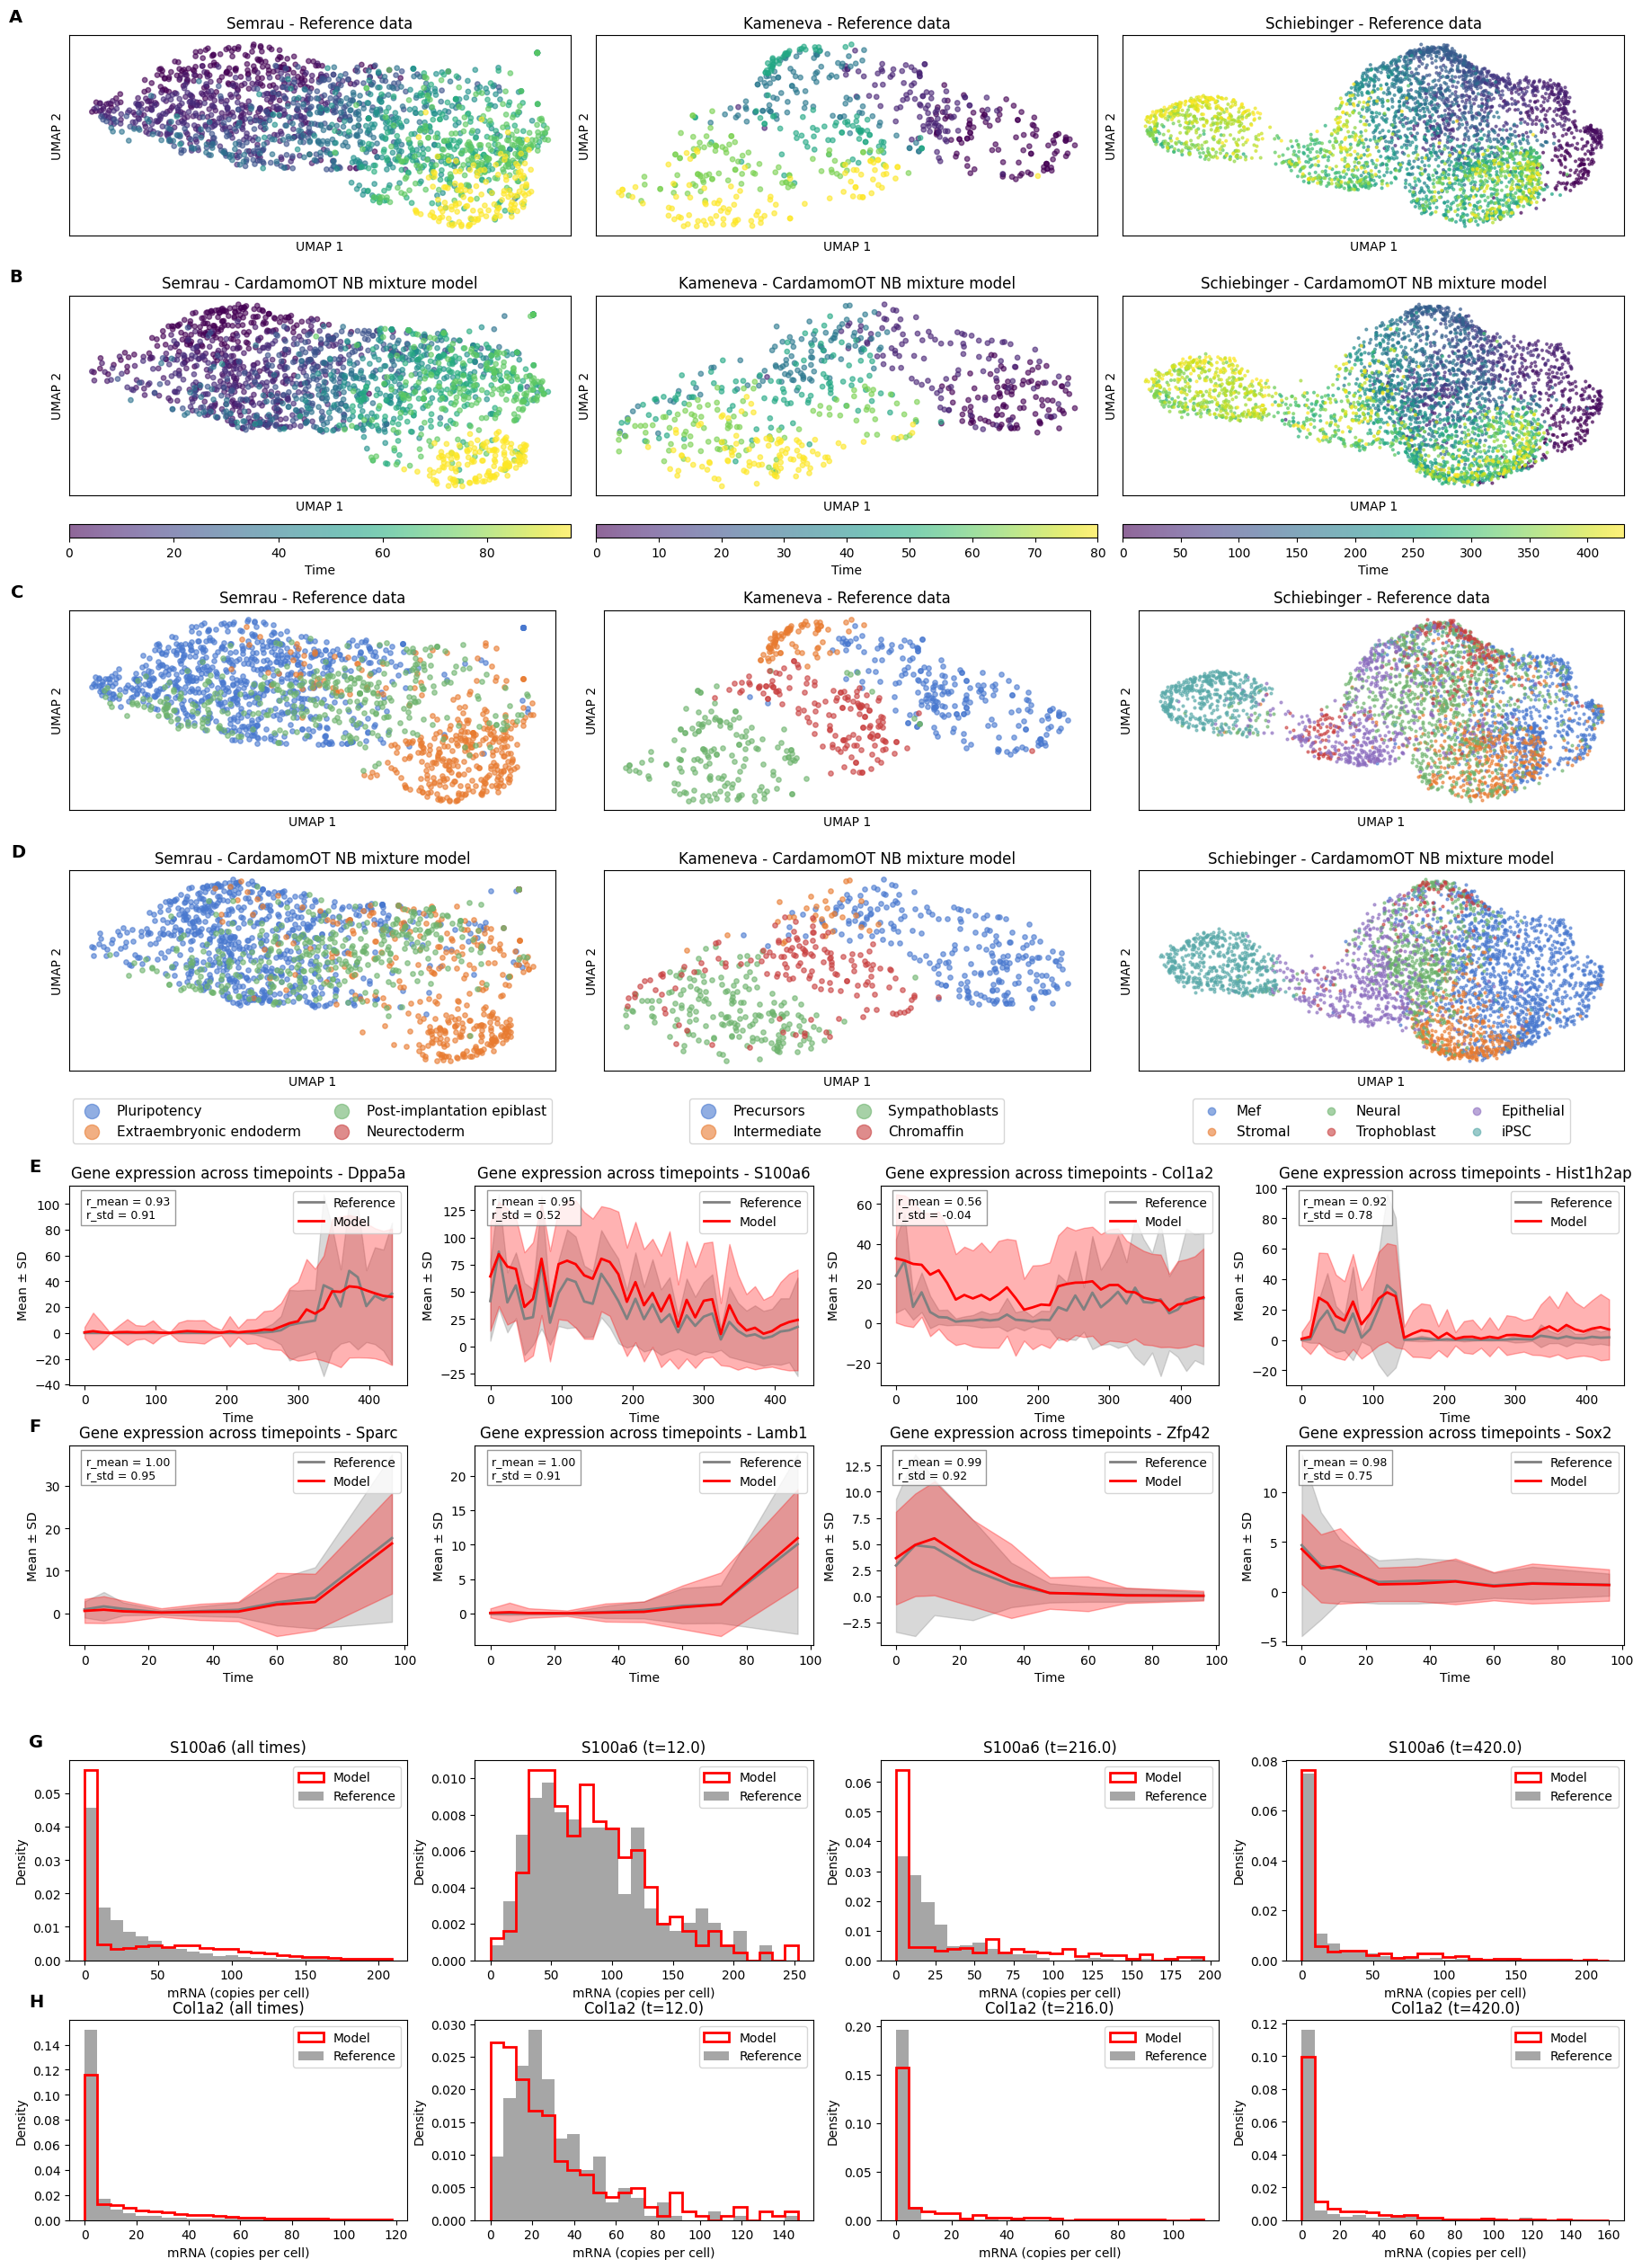

In [29]:
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig = plt.figure(figsize=(22.329, 31.563))
gs = gridspec.GridSpec(4, 1, figure=fig, height_ratios=[2, 2, 2, 2], width_ratios=[1], 
                       hspace=0.25, wspace=0.05)
gs01 = gs[0, :].subgridspec(2, 3, hspace=0.3, wspace=0.05)
gs02 = gs[1, :].subgridspec(2, 3, hspace=0.3, wspace=0.1)
gs03 = gs[2, :].subgridspec(2, 4, hspace=0.3)
gs04 = gs[3, :].subgridspec(2, 4, hspace=0.3)

axes = ([fig.add_subplot(gs01[r, c]) for c in range(3) for r in range(2)] +
        [fig.add_subplot(gs02[r, c]) for c in range(3) for r in range(2)] +
        [fig.add_subplot(gs03[r, c]) for r in range(2) for c in range(4)] +
        [fig.add_subplot(gs04[r, c]) for r in range(2) for c in range(4)])

# Add labels only at the beginning of each major section row
panel_labels = list("ABCDEFGH")
section_starts = [0, 1, 6, 7, 12, 16, 20, 24]  # First axis index of each subrow
for ax_idx, label in zip(section_starts, panel_labels):
    ax = axes[ax_idx]
    ax.text(-0.12, 1.05, label, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=14, fontweight="bold", clip_on=False)

# --- Top-left quadrant (axes 0-5): UMAP colored by time ---
time_umap_configs = [
    (data_semrau_traj_2d, time_semrau, 'Semrau - Reference data', 15),
    (beta_semrau_traj_2d, time_semrau_beta, 'Semrau - CardamomOT NB mixture model', 15),
    (data_olivier_traj_2d, time_olivier, 'Kameneva - Reference data', 15),
    (beta_olivier_traj_2d, time_olivier_beta, 'Kameneva - CardamomOT NB mixture model', 15),
    (data_schiebinger_traj_2d, time_schiebinger, 'Schiebinger - Reference data', 4),
    (beta_schiebinger_traj_2d, time_schiebinger_beta, 'Schiebinger - CardamomOT NB mixture model', 4),
]
for i, (coords, t, title, s) in enumerate(time_umap_configs):
    sc_plot = axes[i].scatter(coords[:, 0], coords[:, 1], c=t, cmap='viridis', alpha=0.6, s=s)
    axes[i].set_xlabel('UMAP 1'); axes[i].set_ylabel('UMAP 2')
    axes[i].set_title(f'{title}')
    axes[i].set_xticks([]); axes[i].set_yticks([])
    # Add colorbar only for mixture model plots (odd indices)
    if i % 2 == 1:
        # Position colorbar below axis, similar to legend positioning
        pos = axes[i].get_position()
        cax = fig.add_axes([pos.x0, pos.y0 - 0.015, pos.width, 0.005])
        plt.colorbar(sc_plot, cax=cax, label='Time', orientation='horizontal')

# --- Top-right quadrant (axes 6-11): UMAP colored by cell type ---
celltype_umap_configs = [
    (data_semrau_traj_2d, cell_types_semrau, unique_cell_types_semrau, celltype_colors_semrau, 'Semrau - Reference data', 15),
    (beta_semrau_traj_2d, cell_types_semrau_beta, unique_cell_types_semrau, celltype_colors_semrau, 'Semrau - CardamomOT NB mixture model', 15),
    (data_olivier_traj_2d, cell_types_olivier, unique_cell_types_olivier, celltype_colors_olivier, 'Kameneva - Reference data', 15),
    (beta_olivier_traj_2d, cell_types_olivier_beta, unique_cell_types_olivier, celltype_colors_olivier, 'Kameneva - CardamomOT NB mixture model', 15),
    (data_schiebinger_traj_2d, cell_types_schiebinger, unique_cell_types_schiebinger, celltype_colors_schiebinger, 'Schiebinger - Reference data', 4),
    (beta_schiebinger_traj_2d, cell_types_schiebinger_beta, unique_cell_types_schiebinger, celltype_colors_schiebinger, 'Schiebinger - CardamomOT NB mixture model', 4),
]
for i, (coords, ct_arr, unique_cts, ct_colors, title, s) in enumerate(celltype_umap_configs):
    ax = axes[6 + i]
    for ct in unique_cts:
        mask = ct_arr == ct
        ax.scatter(coords[mask, 0], coords[mask, 1], c=[ct_colors[ct]], alpha=0.6, s=s, label=ct)
    ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
    ax.set_title(f'{title}')
    ax.set_xticks([]); ax.set_yticks([])
    # Add legend only for mixture model plots (odd indices)
    if i % 2 == 1:
        from matplotlib.axes import Axes
        handles, labels = ax.get_legend_handles_labels()
        # Get the position of the axis in figure coordinates
        pos = ax.get_position()
        # Create inset axes below the current axis
        lax = fig.add_axes([pos.x0, pos.y0 - 0.09, pos.width, 0.08])
        lax.axis('off')
        lax.legend(handles, labels, fontsize=11, markerscale=3, loc='upper center', ncols = 3 if i == 5 else 2, borderaxespad=0)

# --- gs03 row 0 (axes 12-15): Mean ± SD of gene expression by timepoint ---
gene_numbers_1 = [24, 83, 17, 48]
unique_times = np.sort(np.unique(time_schiebinger))
x_data = adata_schiebinger.X.toarray() if scipy.sparse.issparse(adata_schiebinger.X) else adata_schiebinger.X
x_sim = adata_beta_schiebinger.X.toarray() if scipy.sparse.issparse(adata_beta_schiebinger.X) else adata_beta_schiebinger.X

for i, gene_idx in enumerate(gene_numbers_1):
    ax = axes[12 + i]
    means_by_label = {}
    stds_by_label = {}
    for vals, color, label in [(x_data[:, gene_idx], 'grey', 'Reference'),
                                (x_sim[:, gene_idx], 'red', 'Model')]:
        means = np.array([np.mean(vals[adata_schiebinger.obs['time'] == t]) for t in unique_times])
        stds = np.array([np.std(vals[adata_schiebinger.obs['time'] == t]) for t in unique_times])
        means_by_label[label] = means
        stds_by_label[label] = stds
        ax.fill_between(unique_times, means - stds, means + stds, color=color, alpha=0.3)
        ax.plot(unique_times, means, color=color, linewidth=2, label=label)
    r_mean = np.corrcoef(means_by_label['Reference'], means_by_label['Model'])[0, 1]
    r_std = np.corrcoef(stds_by_label['Reference'], stds_by_label['Model'])[0, 1]
    ax.set_xlabel('Time'); ax.set_ylabel('Mean ± SD')
    ax.set_title(f'Gene expression across timepoints - {adata_schiebinger.var_names[gene_idx]}')
    ax.text(0.05, 0.95, f'r_mean = {r_mean:.2f}\nr_std = {r_std:.2f}', transform=ax.transAxes, fontsize=9,
            va='top', ha='left', color='black', bbox=dict(facecolor='white', alpha=0.8, edgecolor='grey'))
    ax.legend()

gene_numbers_2 = [36, 23, 38, 34]
unique_times = np.sort(np.unique(time_semrau))
x_data = adata_semrau.X
x_sim = adata_beta_semrau.X

for i, gene_idx in enumerate(gene_numbers_2):
    ax = axes[16 + i]
    means_by_label = {}
    stds_by_label = {}
    for vals, color, label in [(x_data[:, gene_idx], 'grey', 'Reference'),
                                (x_sim[:, gene_idx], 'red', 'Model')]:
        means = np.array([np.mean(vals[adata_semrau.obs['time'] == t]) for t in unique_times])
        stds = np.array([np.std(vals[adata_semrau.obs['time'] == t]) for t in unique_times])
        means_by_label[label] = means
        stds_by_label[label] = stds
        ax.fill_between(unique_times, means - stds, means + stds, color=color, alpha=0.3)
        ax.plot(unique_times, means, color=color, linewidth=2, label=label)
    r_mean = np.corrcoef(means_by_label['Reference'], means_by_label['Model'])[0, 1]
    r_std = np.corrcoef(stds_by_label['Reference'], stds_by_label['Model'])[0, 1]
    ax.set_xlabel('Time'); ax.set_ylabel('Mean ± SD')
    ax.set_title(f'Gene expression across timepoints - {adata_semrau.var_names[gene_idx]}')
    ax.text(0.05, 0.95, f'r_mean = {r_mean:.2f}\nr_std = {r_std:.2f}', transform=ax.transAxes, fontsize=9,
            va='top', ha='left', color='black', bbox=dict(facecolor='white', alpha=0.8, edgecolor='grey'))
    ax.legend()

# --- gs04 (axes 20-27): Gene expression distributions (2 genes × (all times + 3 timepoints)) ---
gene_numbers_3 = [83, 17]
unique_times = np.sort(np.unique(time_schiebinger))
x_data = adata_schiebinger.X.toarray() if scipy.sparse.issparse(adata_schiebinger.X) else adata_schiebinger.X
x_sim = adata_beta_schiebinger.X.toarray() if scipy.sparse.issparse(adata_beta_schiebinger.X) else adata_beta_schiebinger.X
selected_time_indices = [1, len(unique_times) // 2, -2]
selected_times = unique_times[selected_time_indices]
n_bins = 25

for gene_offset, gene_idx in enumerate(gene_numbers_3):
    # Column 0: all times combined
    ax = axes[20 + gene_offset * 4]
    gene_vals_data = x_data[:, gene_idx]
    gene_vals_sim = x_sim[:, gene_idx]
    n_max = max(np.quantile(gene_vals_data, 0.99), np.quantile(gene_vals_sim, 0.99)) + 1
    bins = np.linspace(0, n_max, n_bins)
    ax.hist(gene_vals_data, density=True, bins=bins, color='grey', histtype='bar', alpha=0.7)
    ax.hist(gene_vals_sim, density=True, bins=bins, ec='red', histtype='step', alpha=1, linewidth=2)
    ax.set_xlabel('mRNA (copies per cell)'); ax.set_ylabel('Density')
    ax.set_title(f'{adata_schiebinger.var_names[gene_idx]} (all times)')
    ax.legend(labels=['Model', 'Reference'])

    # Columns 1-3: individual timepoints
    for tp_idx, time_point in enumerate(selected_times):
        ax = axes[20 + gene_offset * 4 + tp_idx + 1]
        gene_vals_data = x_data[adata_schiebinger.obs['time'] == time_point, gene_idx]
        gene_vals_sim = x_sim[adata_beta_schiebinger.obs['time'] == time_point, gene_idx]
        n_max = max(np.quantile(gene_vals_data, 0.99), np.quantile(gene_vals_sim, 0.99)) + 1
        bins = np.linspace(0, n_max, n_bins)
        ax.hist(gene_vals_data, density=True, bins=bins, color='grey', histtype='bar', alpha=0.7)
        ax.hist(gene_vals_sim, density=True, bins=bins, ec='red', histtype='step', alpha=1, linewidth=2)
        ax.set_xlabel('mRNA (copies per cell)'); ax.set_ylabel('Density')
        ax.set_title(f'{adata_schiebinger.var_names[gene_idx]} (t={time_point:.1f})')
        ax.legend(labels=['Model', 'Reference'])

plt.savefig('figure_2.pdf', dpi=300, bbox_inches='tight', pad_inches=0.05)
plt.show()

In [30]:
# Rescale the PDF to (9.7 x 11.69 inches) using pypdf.
# This scales all content (text, lines, markers) uniformly — font sizes stay visually consistent.
# Install with: pip install pypdf
from pypdf import PdfWriter, PdfReader, Transformation

target_w = 8.27 * 72    # 698.4 pt
target_h = 11.69 * 72  # 841.68 pt

reader = PdfReader("figure_2.pdf")
writer = PdfWriter()
page = reader.pages[0]

orig_w = float(page.mediabox.width)
orig_h = float(page.mediabox.height)
scale = min(target_w / orig_w, target_h / orig_h)

page.add_transformation(Transformation().scale(scale, scale))
page.mediabox.upper_right = (target_w, target_h)

writer.add_page(page)
with open("figure_2_small.pdf", "wb") as f:
    writer.write(f)
print(f"Saved figure_2_small.pdf (scale factor: {scale:.4f})")

Saved figure_2_small.pdf (scale factor: 0.4549)


# Check genes

In [23]:
# Compute variance of expression across time for each gene
unique_times = np.sort(np.unique(time_schiebinger))

x_data_schiebinger = adata_schiebinger.X.toarray() if scipy.sparse.issparse(adata_schiebinger.X) else adata_schiebinger.X
x_sim_schiebinger = adata_beta_schiebinger.X.toarray() if scipy.sparse.issparse(adata_beta_schiebinger.X) else adata_beta_schiebinger.X

# For reference data
var_expr_data = []
for gene_idx in range(adata_schiebinger.n_vars):
    gene_vals = x_data_schiebinger[:, gene_idx]
    timepoint_means = [np.mean(gene_vals[adata_schiebinger.obs['time'] == t]) for t in unique_times]
    var_expr_data.append(np.var(timepoint_means))
var_expr_data = np.array(var_expr_data)

# For simulated data
var_expr_sim = []
for gene_idx in range(adata_beta_schiebinger.n_vars):
    gene_vals = x_sim_schiebinger[:, gene_idx]
    timepoint_means = [np.mean(gene_vals[adata_beta_schiebinger.obs['time'] == t]) for t in unique_times]
    var_expr_sim.append(np.var(timepoint_means))
var_expr_sim = np.array(var_expr_sim)

# Get top 10 most variable genes for reference data
top10_indices_data = np.argsort(var_expr_data)[-10:][::-1]
top10_genes_data = adata_schiebinger.var_names[top10_indices_data]
top10_values_data = var_expr_data[top10_indices_data]

# Get top 10 most variable genes for simulated data
top10_indices_sim = np.argsort(var_expr_sim)[-10:][::-1]
top10_genes_sim = adata_beta_schiebinger.var_names[top10_indices_sim]
top10_values_sim = var_expr_sim[top10_indices_sim]

print("Top 10 most variable genes across time in reference data (adata_schiebinger):")
for i, (idx, gene, val) in enumerate(zip(top10_indices_data, top10_genes_data, top10_values_data), 1):
    print(f"{i}. {gene} (index {idx}): variance = {val:.2f}")

print("\nTop 10 most variable genes across time in simulated data (adata_beta_schiebinger):")
for i, (idx, gene, val) in enumerate(zip(top10_indices_sim, top10_genes_sim, top10_values_sim), 1):
    print(f"{i}. {gene} (index {idx}): variance = {val:.2f}")

Top 10 most variable genes across time in reference data (adata_schiebinger):
1. S100a6 (index 83): variance = 399.59
2. Dppa5a (index 24): variance = 199.89
3. Mgp (index 58): variance = 168.10
4. Hist1h2ap (index 48): variance = 76.02
5. Col1a2 (index 17): variance = 47.54
6. Krt8 (index 54): variance = 25.67
7. Bgn (index 6): variance = 21.58
8. Ube2s (index 99): variance = 18.40
9. Gm26917 (index 43): variance = 16.85
10. Xist (index 105): variance = 16.29

Top 10 most variable genes across time in simulated data (adata_beta_schiebinger):
1. S100a6 (index 83): variance = 537.37
2. Dppa5a (index 24): variance = 164.08
3. Mgp (index 58): variance = 118.20
4. Hist1h2ap (index 48): variance = 81.86
5. Col1a2 (index 17): variance = 47.23
6. Gm26917 (index 43): variance = 28.83
7. Ube2s (index 99): variance = 25.75
8. Bgn (index 6): variance = 14.26
9. Xist (index 105): variance = 11.84
10. Thbs1 (index 94): variance = 11.68
